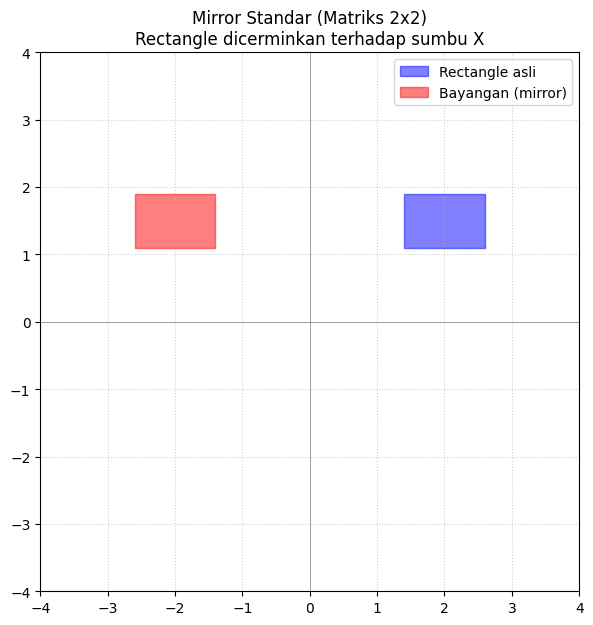

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider
from matplotlib.patches import Polygon

# Fungsi transformasi dan pembuatan kotak (tidak ada perubahan di sini)
def mirror_standard(points):
    M = np.array([[-1, 0],
                  [0, 1]])
    return (M @ points.T).T

def get_rectangle_vertices(center_x, center_y, width=1.2, height=0.8):
    half_w = width / 2
    half_h = height / 2
    local = np.array([
        [-half_w, -half_h],
        [ half_w, -half_h],
        [ half_w,  half_h],
        [-half_w,  half_h]
    ])
    return local + np.array([center_x, center_y])

# Setup awal (dieksekusi sekali)
limit = 4
width, height = 1.2, 0.8
init_x, init_y = 2.0, 1.5

# Buat figure dan axis (hanya sekali)
fig, ax = plt.subplots(figsize=(7, 7))

ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
ax.grid(True, linestyle=':', alpha=0.6)
ax.set_aspect('equal')
ax.set_title("Mirror Standar (Matriks 2x2)\nRectangle dicerminkan terhadap sumbu X")

# Inisialisasi polygon (akan di-update oleh fungsi interaktif)
new_orig = get_rectangle_vertices(init_x, init_y, width, height)
new_mirror = mirror_standard(new_orig)

poly_orig = Polygon(new_orig, closed=True, facecolor='blue', alpha=0.5, edgecolor='blue', label='Rectangle asli')
poly_mirror = Polygon(new_mirror, closed=True, facecolor='red', alpha=0.5, edgecolor='red', label='Bayangan (mirror)')

ax.add_patch(poly_orig)
ax.add_patch(poly_mirror)
ax.legend(loc='upper right')

# Fungsi untuk update plot berdasarkan slider
def update_plot(cx, cy):
    # Hitung vertex baru
    new_orig = get_rectangle_vertices(cx, cy, width, height)
    new_mirror = mirror_standard(new_orig)
    
    # Update polygon
    poly_orig.set_xy(new_orig)
    poly_mirror.set_xy(new_mirror)
    
    # Update title untuk info pusat
    ax.set_title(f"Mirror Standar (Matriks 2x2)\nPusat asli: ({cx:.2f}, {cy:.2f}) | Pusat bayangan: ({-cx:.2f}, {cy:.2f})")
    
    # Redraw canvas (wajib untuk %matplotlib widget)
    fig.canvas.draw_idle()

# Buat slider interaktif dan kaitkan dengan fungsi update
interact(
    update_plot,
    cx=FloatSlider(min=-3, max=3, step=0.05, value=init_x, description='Pusat x'),
    cy=FloatSlider(min=-3, max=3, step=0.05, value=init_y, description='Pusat y')
)